#### 渐进式披露
> 初始只加载metadata，按需加载skill。对于加载的skill也是只加载主体内容，必要情况下再加载参考文件

#### skills、prompt、subagent、MCP

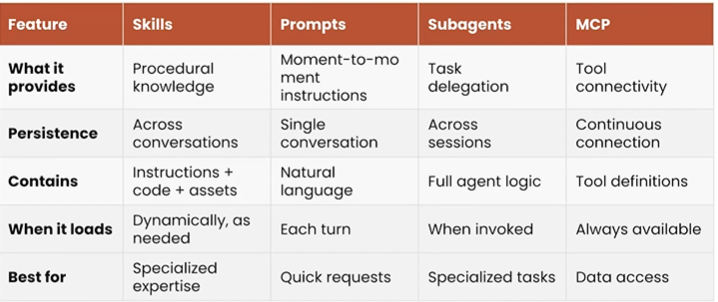

### skill主要结构

- skill.md

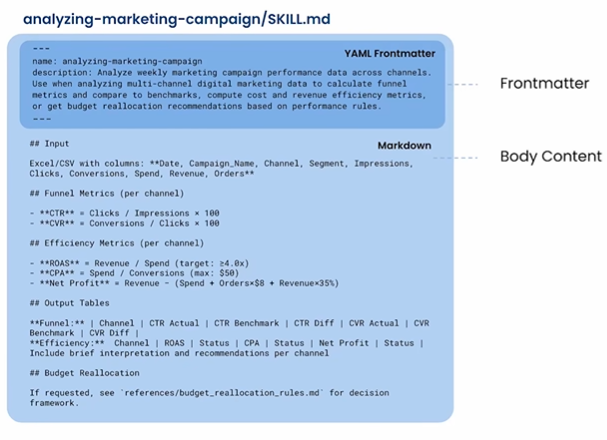

名称（名称有格式要求，包含小写字母、数字、连字符）和描述：给出skill的主要功能以及何时触发，告知智能体何时使用该技能。还包括其他的可选字段：许可证等等。

正文：skill的主体，需要清晰简洁的给出一个工作流的流程，可以引用外部脚本、外部文件等。过于复杂的工作流可以拆解成多个skill，防止单个skill过于复杂。

- 其他文件夹

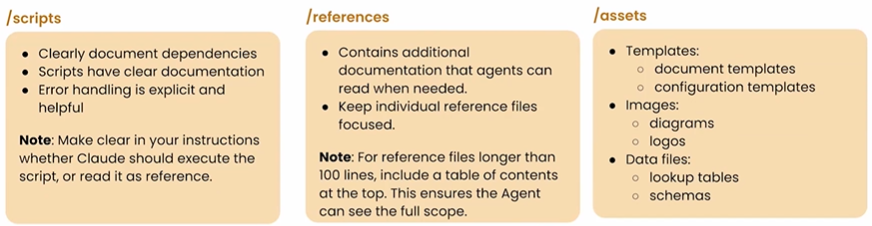

scripts：可执行脚本，比如 Python 脚本、Shell 脚本、JavaScript 脚本、自动化任务代码、数据处理脚本、API 调用工具脚本等，是 Skill 实现自动化能力的核心载体。

>必须清晰标注依赖：要明确写清脚本运行所需的依赖（比如 Python 的 requirements.txt、脚本里 import 的第三方库、运行环境要求），让 AI 在执行前能完成环境准备，避免运行失败。

>脚本必须附带清晰的文档：每个脚本都要有完整的注释 / 说明，包括脚本的用途、适用场景、入参出参定义、执行步骤、注意事项，让 AI 能精准理解 “这个脚本什么时候用、怎么用”。

>必须有明确且友好的错误处理：脚本内要做好异常捕获和错误提示，出错时能给出明确的失败原因和可落地的修复建议，而非直接崩溃，帮助 AI（或使用者）快速定位问题。

reference：存放给 AI Agent 提供上下文、规则、背景知识的纯参考类文档,比如业务规则手册、API 接口文档、项目背景说明、行业规范、操作流程、需求文档、设计文档、历史案例、术语定义、权限规则等，是整个 Skill 的 “认知层”，AI 仅需读取理解内容，不会执行这里的文件。

> 作为 AI 的补充知识库：这里的文档是 AI 完成任务的参考依据，当 AI 遇到相关问题时，可快速检索对应文档，获取规则、知识和标准，保证输出内容、执行动作符合业务要求。

> 单个参考文件必须主题聚焦：每个文档只围绕一个主题 / 一个模块编写，不要把不相关的内容堆砌在同一个文件里。比如API调用规范.md只讲 API 相关规则，用户权限说明.md只讲权限逻辑，让 AI 能快速定位目标信息，不被无关内容干扰。

assets：存放项目中用到的、非代码 / 非纯文本的静态资源文件，是整个 Skill 的 “素材库”，脚本、文档里会引用这里的内容，实现资源的统一管理和复用。

核心存放内容，分为三大类：

> Templates 模板文件存放各类标准化模板，包括文档模板（报告模板、邮件模板、合同模板、发文模板等）、配置模板（YAML/JSON 配置模板、环境配置模板等）。AI 可以直接调用这些模板，填充对应内容生成符合规范的文件，无需从零编写，保证输出格式的统一和合规。

> Images 图片资源存放项目用到的各类图片文件，包括架构图、流程图、业务示意图等 diagrams，以及品牌 logo、图标等素材。这些图片会被文档、报告引用，AI 可以在生成内容时插入对应图片，也可以参考图片里的架构、流程信息完成任务。

> Data files 数据文件存放项目用到的静态基础数据文件，包括 lookup tables（查询表、编码映射表、参数对照表、枚举值表等）、schemas（数据结构定义、数据库表结构、JSON Schema、接口结构定义等）。这些是 AI 执行脚本、处理数据、校验格式时用到的基础规则和数据，保证数据处理的规范性和准确性。


### 调用Claude API使用skill的方法